# Decision Threshold Analysis

## Overview & Purpose
This notebook performs decision threshold optimization and risk stratification for the credit default risk scoring model without retraining or altering calibrated predicted probabilities.

### Key Objectives:
1. **Artifact Ingestion:** Load the final trained XGBoost model and untouched test set predictions/probabilities from previous pipeline steps.
2. **Multi-Threshold Evaluation:** Assess classification performance across decision thresholds from $0.05$ to $0.95$ in step increments of $0.05$.
3. **Metric Analysis:** Compute confusion matrices, Precision, Recall (Sensitivity), Specificity, F1 Score, Accuracy, and Balanced Accuracy across all thresholds.
4. **Trade-off Examination:** Analyze precision-recall and threshold-dependent performance curves to identify optimal operational decision boundaries.
5. **Optimal Threshold Identification:** Identify specific optimal decision thresholds based on explicit optimization criteria (e.g., Maximum F1 Score, Maximum Balanced Accuracy).
6. **Risk Segmentation:** Categorize test predictions into actionable credit risk tiers (Low, Medium, High, Very High Risk) and evaluate observed vs. predicted default rates per band.
7. **Artifact Export:** Save all summary evaluation tables, prediction outputs, and metric plots for model governance and reporting.

In [11]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from IPython.display import display

#### Define artifact paths

In [ ]:
ARTIFACT_DIR = os.path.join(
    "outputs",
    "final_artifacts"
)

OUTPUT_DIR_9 = os.path.join(
    "outputs",
    "notebook_9"
)

os.makedirs(OUTPUT_DIR_9, exist_ok=True)

print("Artifact directory:", ARTIFACT_DIR)
print("Notebook 9 output directory:", OUTPUT_DIR_9)

Artifact directory: outputs\final_artifacts
Notebook 9 output directory: outputs\notebook_9


#### Verify artifacts

In [5]:
ARTIFACT_DIR = os.path.join("notebook8_outputs", "final_artifacts") 

required_files = [
    "final_base_model.joblib",
    "X_model_train.joblib",
    "y_model_train.joblib",
    "X_calibration.joblib",
    "y_calibration.joblib",
    "X_test.joblib",
    "y_test.joblib",
    "train_prob.joblib",
    "calibration_prob.joblib",
    "test_prob.joblib"
]

missing_files = [
    f for f in required_files
    if not os.path.exists(os.path.join(ARTIFACT_DIR, f))
]

if missing_files:
    raise FileNotFoundError(
        "Missing artifacts:\n" +
        "\n".join(missing_files)
    )

print("✓ All required artifacts found.")

✓ All required artifacts found.


#### Load final model and data

In [19]:
import os
import joblib

ARTIFACT_DIR = os.path.join("notebook8_outputs", "final_artifacts")

# Load artifacts
final_base_model = joblib.load(os.path.join(ARTIFACT_DIR, "final_base_model.joblib"))
X_model_train = joblib.load(os.path.join(ARTIFACT_DIR, "X_model_train.joblib"))
y_model_train = joblib.load(os.path.join(ARTIFACT_DIR, "y_model_train.joblib"))
X_calibration = joblib.load(os.path.join(ARTIFACT_DIR, "X_calibration.joblib"))
y_calibration = joblib.load(os.path.join(ARTIFACT_DIR, "y_calibration.joblib"))
X_test = joblib.load(os.path.join(ARTIFACT_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(ARTIFACT_DIR, "y_test.joblib"))
train_prob = joblib.load(os.path.join(ARTIFACT_DIR, "train_prob.joblib"))
calibration_prob = joblib.load(os.path.join(ARTIFACT_DIR, "calibration_prob.joblib"))
test_prob = joblib.load(os.path.join(ARTIFACT_DIR, "test_prob.joblib"))

print("✓ Artifacts loaded successfully from:", ARTIFACT_DIR)

✓ Artifacts loaded successfully from: notebook8_outputs\final_artifacts


In [20]:
import os

candidate_dirs = [
    os.path.join("outputs", "final_artifacts"),
    os.path.join("outputs", "notebook_8"),
    os.path.join("notebook8_outputs", "final_artifacts"),
    "notebook8_outputs",
    "final_artifacts"
]

print("=== Directory Inspection ===")
for path in candidate_dirs:
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"\n[FOUND] '{path}' containing {len(files)} files:")
        for f in sorted(files):
            if f.endswith(".joblib"):
                print(f"  - {f}")
    else:
        print(f"[NOT FOUND] '{path}'")

=== Directory Inspection ===
[NOT FOUND] 'outputs\final_artifacts'
[NOT FOUND] 'outputs\notebook_8'

[FOUND] 'notebook8_outputs\final_artifacts' containing 12 files:
  - X_calibration.joblib
  - X_model_train.joblib
  - X_test.joblib
  - calibration_prob.joblib
  - final_base_model.joblib
  - permutation_importance_df.joblib
  - shap_original_df.joblib
  - test_prob.joblib
  - train_prob.joblib
  - y_calibration.joblib
  - y_model_train.joblib
  - y_test.joblib

[FOUND] 'notebook8_outputs' containing 20 files:
[NOT FOUND] 'final_artifacts'


#### Verify shapes

In [21]:
print("=" * 75)
print("SHAPE VERIFICATION")
print("=" * 75)

print("X_model_train:", X_model_train.shape)
print("y_model_train:", y_model_train.shape)

print("X_calibration:", X_calibration.shape)
print("y_calibration:", y_calibration.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("train_prob:", train_prob.shape)
print("calibration_prob:", calibration_prob.shape)
print("test_prob:", test_prob.shape)

SHAPE VERIFICATION
X_model_train: (19200, 23)
y_model_train: (19200,)
X_calibration: (4800, 23)
y_calibration: (4800,)
X_test: (6000, 23)
y_test: (6000,)
train_prob: (19200,)
calibration_prob: (4800,)
test_prob: (6000,)


#### Verify probability alignment

In [22]:
assert len(X_model_train) == len(y_model_train) == len(train_prob)
assert len(X_calibration) == len(y_calibration) == len(calibration_prob)
assert len(X_test) == len(y_test) == len(test_prob)

assert np.all((test_prob >= 0) & (test_prob <= 1))

print("✓ Probability alignment passed.")
print("✓ Test probabilities are within [0, 1].")

✓ Probability alignment passed.
✓ Test probabilities are within [0, 1].


#### Confirm test ROC-AUC

In [23]:
test_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

print("Test ROC-AUC:", round(test_roc_auc, 6))
print("Test PR-AUC:", round(test_pr_auc, 6))

Test ROC-AUC: 0.780532
Test PR-AUC: 0.560152


#### Define thresholds

In [24]:
thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

print(
    "Number of thresholds:",
    len(thresholds)
)

print(
    "Threshold range:",
    thresholds.min(),
    "to",
    thresholds.max()
)

Number of thresholds: 91
Threshold range: 0.05 to 0.9500000000000002


#### Calculate threshold metrics

In [25]:
threshold_results = []

for threshold in thresholds:

    y_pred = (
        test_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "NPV": npv,
        "F1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df.head()

,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,NPV,F1,TN,FP,FN,TP
0,0.05,0.270833,0.528108,0.231406,0.989450,0.066767,0.957055,0.375089,312,4361,14,1313
1,0.06,0.307667,0.549596,0.240022,0.983421,0.115771,0.960924,0.385866,541,4132,22,1305
2,0.07,0.348833,0.571978,0.250000,0.972118,0.171838,0.955952,0.397719,803,3870,37,1290
3,0.08,0.385667,0.589419,0.258941,0.954785,0.224053,0.945799,0.407395,1047,3626,60,1267
4,0.09,0.422500,0.606591,0.268815,0.936699,0.276482,0.938953,0.417745,1292,3381,84,1243


#### Display threshold performance

In [26]:
display(
    threshold_results_df.round(4)
)

,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,NPV,F1,TN,FP,FN,TP
0,0.05,0.2708,0.5281,0.2314,0.9894,0.0668,0.9571,0.3751,312,4361,14,1313
1,0.06,0.3077,0.5496,0.2400,0.9834,0.1158,0.9609,0.3859,541,4132,22,1305
2,0.07,0.3488,0.5720,0.2500,0.9721,0.1718,0.9560,0.3977,803,3870,37,1290
3,0.08,0.3857,0.5894,0.2589,0.9548,0.2241,0.9458,0.4074,1047,3626,60,1267
4,0.09,0.4225,0.6066,0.2688,0.9367,0.2765,0.9390,0.4177,1292,3381,84,1243
...,...,...,...,...,...,...,...,...,...,...,...,...
86,0.91,0.7788,0.5000,0.0000,0.0000,1.0000,0.7788,0.0000,4673,0,1327,0
87,0.92,0.7788,0.5000,0.0000,0.0000,1.0000,0.7788,0.0000,4673,0,1327,0
88,0.93,0.7788,0.5000,0.0000,0.0000,1.0000,0.7788,0.0000,4673,0,1327,0
89,0.94,0.7788,0.5000,0.0000,0.0000,1.0000,0.7788,0.0000,4673,0,1327,0


#### Find metric-specific thresholds

In [27]:
threshold_by_metric = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity"
    ],
    "Threshold": [
        threshold_results_df.loc[
            threshold_results_df["Accuracy"].idxmax(),
            "Threshold"
        ],
        threshold_results_df.loc[
            threshold_results_df["Balanced Accuracy"].idxmax(),
            "Threshold"
        ],
        threshold_results_df.loc[
            threshold_results_df["Precision"].idxmax(),
            "Threshold"
        ],
        threshold_results_df.loc[
            threshold_results_df["Recall"].idxmax(),
            "Threshold"
        ],
        threshold_results_df.loc[
            threshold_results_df["F1"].idxmax(),
            "Threshold"
        ],
        threshold_results_df.loc[
            threshold_results_df["Specificity"].idxmax(),
            "Threshold"
        ]
    ]
})

display(
    threshold_by_metric.round(4)
)

,Metric,Threshold
0,Accuracy,0.49
1,Balanced Accuracy,0.23
2,Precision,0.87
3,Recall,0.05
4,F1,0.24
5,Specificity,0.87


#### F1 threshold

In [28]:
f1_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

print(
    "Threshold with maximum F1:",
    round(f1_threshold_row["Threshold"], 4)
)

display(
    f1_threshold_row.to_frame().T.round(4)
)

Threshold with maximum F1: 0.24


,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,NPV,F1,TN,FP,FN,TP
19,0.24,0.7797,0.7174,0.5016,0.6059,0.829,0.8811,0.5488,3874.0,799.0,523.0,804.0


#### Balanced accuracy threshold

In [29]:
balanced_accuracy_row = threshold_results_df.loc[
    threshold_results_df["Balanced Accuracy"].idxmax()
]

print(
    "Threshold with maximum balanced accuracy:",
    round(
        balanced_accuracy_row["Threshold"],
        4
    )
)

display(
    balanced_accuracy_row.to_frame().T.round(4)
)

Threshold with maximum balanced accuracy: 0.23


,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,NPV,F1,TN,FP,FN,TP
18,0.23,0.7715,0.7181,0.487,0.6225,0.8138,0.8836,0.5465,3803.0,870.0,501.0,826.0


#### Precision-recall trade-off

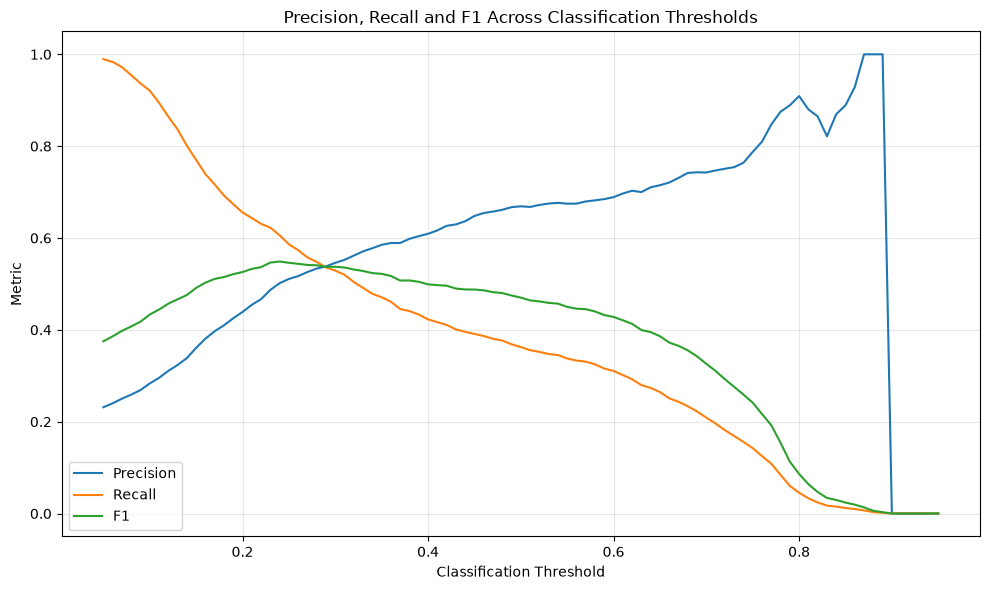

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1"],
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Metric")
plt.title("Precision, Recall and F1 Across Classification Thresholds")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_9,
        "threshold_precision_recall_f1.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Sensitivity/specificity curve

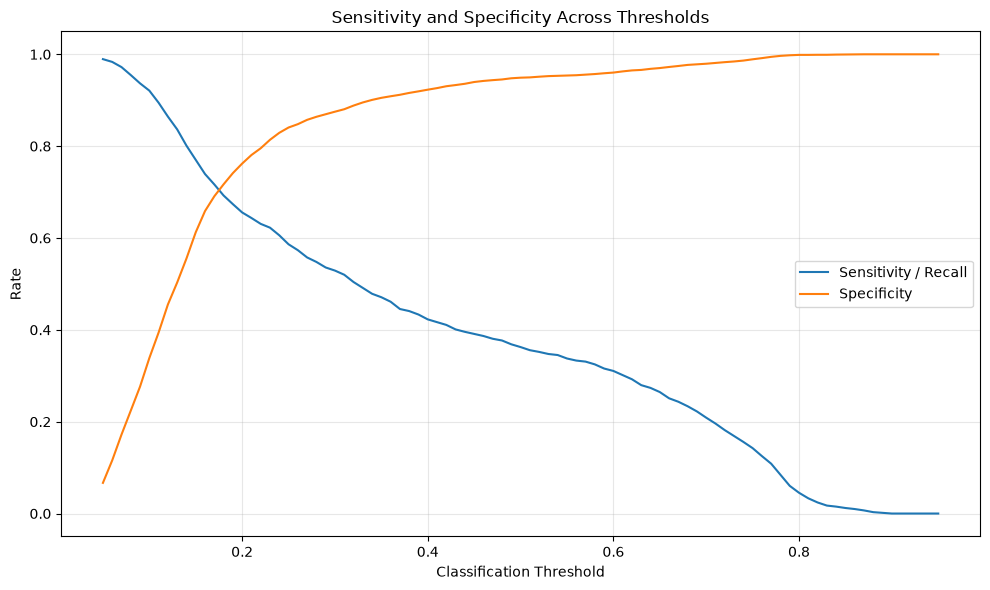

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    label="Sensitivity / Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Specificity"],
    label="Specificity"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Rate")
plt.title("Sensitivity and Specificity Across Thresholds")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_9,
        "threshold_sensitivity_specificity.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Confusion matrices for selected thresholds

In [32]:
selected_thresholds = {
    "0.50": 0.50,
    "F1_threshold": float(
        f1_threshold_row["Threshold"]
    )
}

for name, threshold in selected_thresholds.items():

    y_pred = (
        test_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("=" * 60)
    print(name)
    print("Threshold:", round(threshold, 4))
    print("=" * 60)
    print(cm)

0.50
Threshold: 0.5
[[4435  238]
 [ 846  481]]
F1_threshold
Threshold: 0.24
[[3874  799]
 [ 523  804]]


#### Detailed metrics for selected thresholds

In [33]:
selected_threshold_results = []

for name, threshold in selected_thresholds.items():

    y_pred = (
        test_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    selected_threshold_results.append({
        "Threshold Name": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Specificity": (
            tn / (tn + fp)
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

selected_threshold_results_df = pd.DataFrame(
    selected_threshold_results
)

display(
    selected_threshold_results_df.round(4)
)

,Threshold Name,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,TN,FP,FN,TP
0,0.50,0.50,0.8193,0.6558,0.6690,0.3625,0.9491,0.4702,4435,238,846,481
1,F1_threshold,0.24,0.7797,0.7174,0.5016,0.6059,0.8290,0.5488,3874,799,523,804


#### Classification reports

In [34]:
for name, threshold in selected_thresholds.items():

    y_pred = (
        test_prob >= threshold
    ).astype(int)

    print("=" * 75)
    print(name)
    print("Threshold:", round(threshold, 4))
    print("=" * 75)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Non-Default",
                "Default"
            ],
            zero_division=0
        )
    )

0.50
Threshold: 0.5
              precision    recall  f1-score   support

 Non-Default       0.84      0.95      0.89      4673
     Default       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

F1_threshold
Threshold: 0.24
              precision    recall  f1-score   support

 Non-Default       0.88      0.83      0.85      4673
     Default       0.50      0.61      0.55      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.72      0.70      6000
weighted avg       0.80      0.78      0.79      6000



#### Risk segmentation

In [35]:
risk_data = pd.DataFrame({
    "Actual_Default": np.asarray(y_test),
    "Predicted_Probability": np.asarray(test_prob)
})

risk_data["Risk_Group"] = pd.cut(
    risk_data["Predicted_Probability"],
    bins=[
        0.00,
        0.10,
        0.20,
        0.30,
        0.50,
        1.00
    ],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ],
    include_lowest=True
)

risk_summary = (
    risk_data
    .groupby(
        "Risk_Group",
        observed=False
    )
    .agg(
        Customers=("Actual_Default", "size"),
        Mean_Probability=(
            "Predicted_Probability",
            "mean"
        ),
        Actual_Default_Rate=(
            "Actual_Default",
            "mean"
        )
    )
    .reset_index()
)

risk_summary["Calibration_Error"] = (
    risk_summary["Actual_Default_Rate"]
    - risk_summary["Mean_Probability"]
)

display(
    risk_summary.round(6)
)

,Risk_Group,Customers,Mean_Probability,Actual_Default_Rate,Calibration_Error
0,Very Low,1687,0.068874,0.062241,-0.006634
1,Low,2331,0.141765,0.151008,0.009243
2,Moderate,696,0.240515,0.241379,0.000864
3,High,567,0.380088,0.389771,0.009682
4,Very High,719,0.694706,0.668985,-0.025721


#### Risk-group distribution

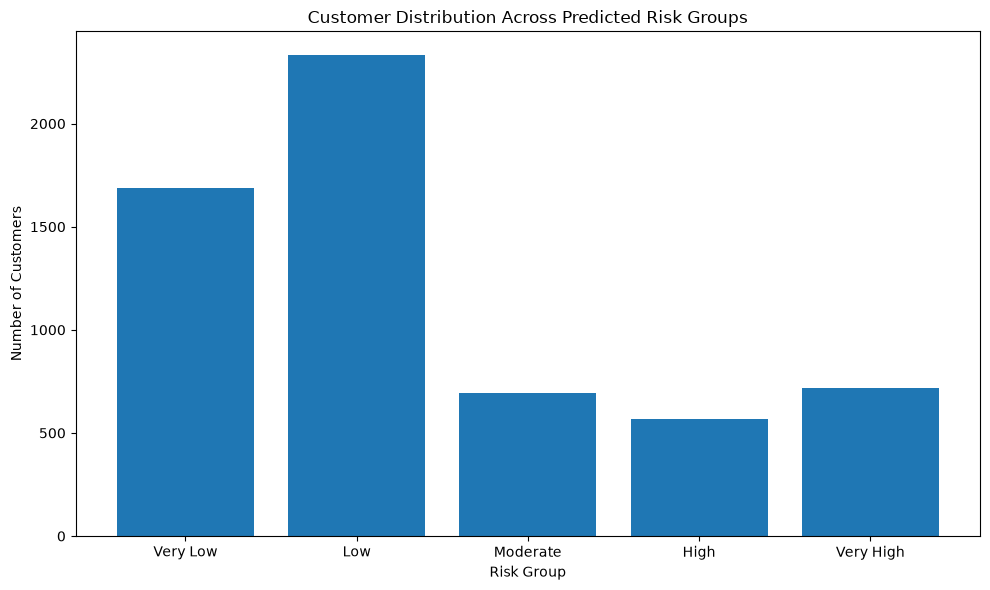

In [36]:
plt.figure(figsize=(10, 6))

plt.bar(
    risk_summary["Risk_Group"].astype(str),
    risk_summary["Customers"]
)

plt.xlabel("Risk Group")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution Across Predicted Risk Groups")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_9,
        "risk_group_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Predicted vs actual default rate by risk group

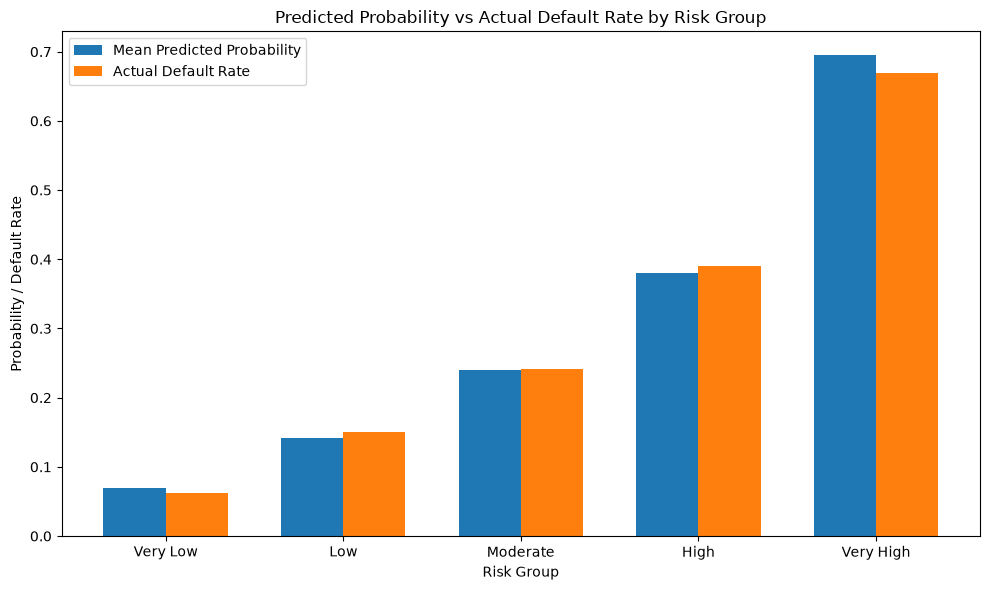

In [37]:
x = np.arange(
    len(risk_summary)
)

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    risk_summary["Mean_Probability"],
    width,
    label="Mean Predicted Probability"
)

plt.bar(
    x + width / 2,
    risk_summary["Actual_Default_Rate"],
    width,
    label="Actual Default Rate"
)

plt.xticks(
    x,
    risk_summary["Risk_Group"].astype(str)
)

plt.xlabel("Risk Group")
plt.ylabel("Probability / Default Rate")
plt.title(
    "Predicted Probability vs Actual Default Rate by Risk Group"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR_9,
        "risk_group_calibration.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### High-risk customer statistics

In [38]:
high_risk_mask = (
    risk_data["Predicted_Probability"] >= 0.50
)

high_risk_customers = risk_data.loc[
    high_risk_mask
]

print(
    "Customers with predicted probability >= 0.50:",
    len(high_risk_customers)
)

print(
    "Proportion of test set:",
    round(
        len(high_risk_customers) / len(risk_data),
        6
    )
)

if len(high_risk_customers) > 0:
    print(
        "Actual default rate among these customers:",
        round(
            high_risk_customers["Actual_Default"].mean(),
            6
        )
    )

Customers with predicted probability >= 0.50: 719
Proportion of test set: 0.119833
Actual default rate among these customers: 0.668985


#### Export threshold results

In [39]:
threshold_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR_9,
        "threshold_analysis.csv"
    ),
    index=False
)

threshold_by_metric.to_csv(
    os.path.join(
        OUTPUT_DIR_9,
        "threshold_by_metric.csv"
    ),
    index=False
)

selected_threshold_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR_9,
        "selected_threshold_results.csv"
    ),
    index=False
)

risk_summary.to_csv(
    os.path.join(
        OUTPUT_DIR_9,
        "risk_group_summary.csv"
    ),
    index=False
)

risk_data.to_csv(
    os.path.join(
        OUTPUT_DIR_9,
        "test_customer_risk_data.csv"
    ),
    index=False
)

print("✓ Notebook 9 tables saved.")

✓ Notebook 9 tables saved.


#### Summary

In [40]:
print("=" * 75)
print("NOTEBOOK 9 - FINAL SUMMARY")
print("=" * 75)

print("\nTEST PERFORMANCE")
print("-" * 75)

print(
    f"ROC-AUC: {test_roc_auc:.6f}"
)

print(
    f"PR-AUC: {test_pr_auc:.6f}"
)

print("\nTHRESHOLD ANALYSIS")
print("-" * 75)

print(
    f"Maximum F1 threshold: "
    f"{f1_threshold_row['Threshold']:.4f}"
)

print(
    f"Maximum F1: "
    f"{f1_threshold_row['F1']:.6f}"
)

print(
    f"Maximum balanced accuracy threshold: "
    f"{balanced_accuracy_row['Threshold']:.4f}"
)

print(
    f"Maximum balanced accuracy: "
    f"{balanced_accuracy_row['Balanced Accuracy']:.6f}"
)

print("\nRISK GROUPS")
print("-" * 75)

display(
    risk_summary.round(6)
)

print("\nOUTPUT FILES")
print("-" * 75)

for filename in sorted(
    os.listdir(OUTPUT_DIR_9)
):
    print(filename)

print("\nNotebook 9 completed.")

NOTEBOOK 9 - FINAL SUMMARY

TEST PERFORMANCE
---------------------------------------------------------------------------
ROC-AUC: 0.780532
PR-AUC: 0.560152

THRESHOLD ANALYSIS
---------------------------------------------------------------------------
Maximum F1 threshold: 0.2400
Maximum F1: 0.548805
Maximum balanced accuracy threshold: 0.2300
Maximum balanced accuracy: 0.718140

RISK GROUPS
---------------------------------------------------------------------------


,Risk_Group,Customers,Mean_Probability,Actual_Default_Rate,Calibration_Error
0,Very Low,1687,0.068874,0.062241,-0.006634
1,Low,2331,0.141765,0.151008,0.009243
2,Moderate,696,0.240515,0.241379,0.000864
3,High,567,0.380088,0.389771,0.009682
4,Very High,719,0.694706,0.668985,-0.025721



OUTPUT FILES
---------------------------------------------------------------------------
risk_group_calibration.png
risk_group_distribution.png
risk_group_summary.csv
selected_threshold_results.csv
test_customer_risk_data.csv
threshold_analysis.csv
threshold_by_metric.csv
threshold_precision_recall_f1.png
threshold_sensitivity_specificity.png

Notebook 9 completed.
